In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/creditcard.csv')

# Вывод первых 5 строк
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
# Базовая сводка по данным
df.info()

# Описательная статистика (числовые признаки)
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Описание признаков

*   **Time**: Количество секунд, прошедших между этой транзакцией и первой транзакцией в наборе данных.
*   **Amount**: Сумма транзакции.
*   **V1-V28**: Анонимизированные признаки, которые могут быть результатом PCA-преобразования для защиты конфиденциальности пользователей.
*   **Class**: Целевая переменная (1 - мошенничество, 0 - обычная транзакция).

Class
0    284315
1       492
Name: count, dtype: int64


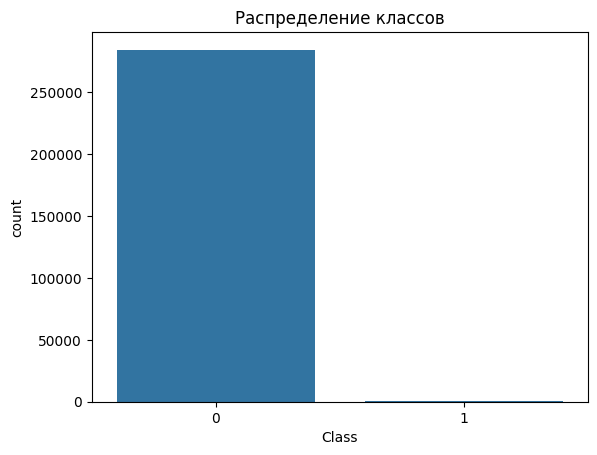

In [2]:
print(df['Class'].value_counts())

# Визуализация распределения классов
sns.countplot(x='Class', data=df)
plt.title('Распределение классов')
plt.show()

### Борьба с дисбалансом классов: Undersampling (как эксперимент)

Ниже мы сделаем простой undersampling, чтобы **визуально** и на маленьком примере увидеть поведение на сбалансированных данных.

Важно: **дальше в baseline/сравнении/Optuna мы обучаемся на полном датасете** (со всеми объектами), а дисбаланс учитываем через веса (`class_weight`, `scale_pos_weight`).

In [ ]:
# Отделяем мошеннические и обычные транзакции
fraud_df = df[df['Class'] == 1]
non_fraud_df = df[df['Class'] == 0]

# Случайно выбираем обычные транзакции в том же количестве, что и мошеннические
non_fraud_sample = non_fraud_df.sample(n=len(fraud_df), random_state=42)

# Создаём новый сбалансированный датафрейм
balanced_df = pd.concat([fraud_df, non_fraud_sample])

# Перемешиваем данные
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Новое распределение классов:')
print(balanced_df['Class'].value_counts())

# Визуализация
sns.countplot(x='Class', data=balanced_df)
plt.title('Сбалансированное распределение классов (undersampling)')
plt.show()

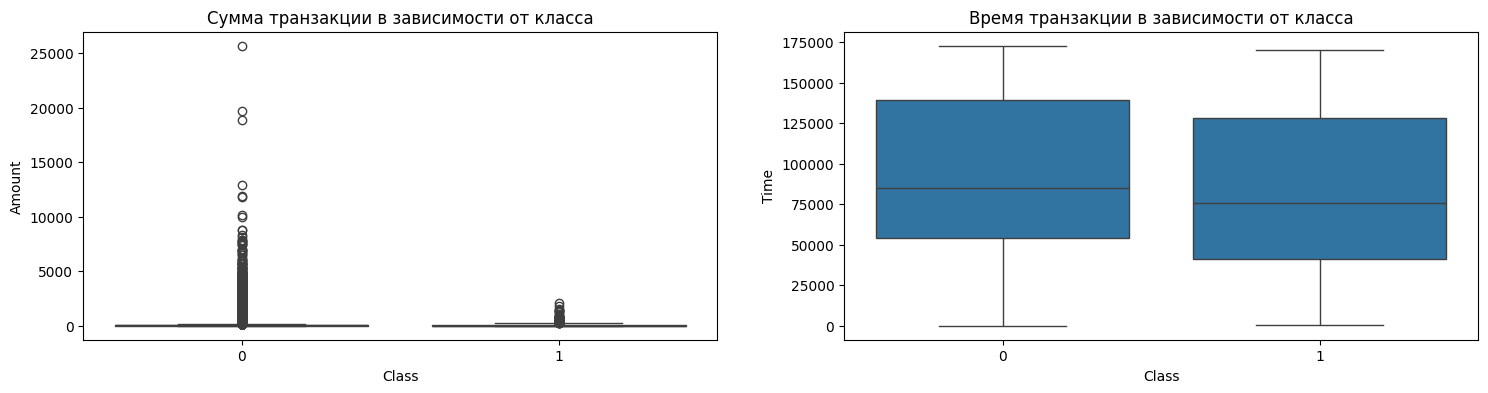

In [24]:
# Boxplots for raw interpretables (Time/Amount)
if {'Amount', 'Time'}.issubset(df.columns):
    fig, ax = plt.subplots(1, 2, figsize=(18, 4))

    sns.boxplot(x='Class', y='Amount', data=df, ax=ax[0])
    ax[0].set_title('Amount by class')

    sns.boxplot(x='Class', y='Time', data=df, ax=ax[1])
    ax[1].set_title('Time by class')

    plt.show()
else:
    print('Skipping boxplots: Time/Amount are not available (likely already scaled & dropped).')


### `Time` и `Amount` в зависимости от класса

Сравним распределения `Time` и `Amount` для мошеннических и обычных транзакций.

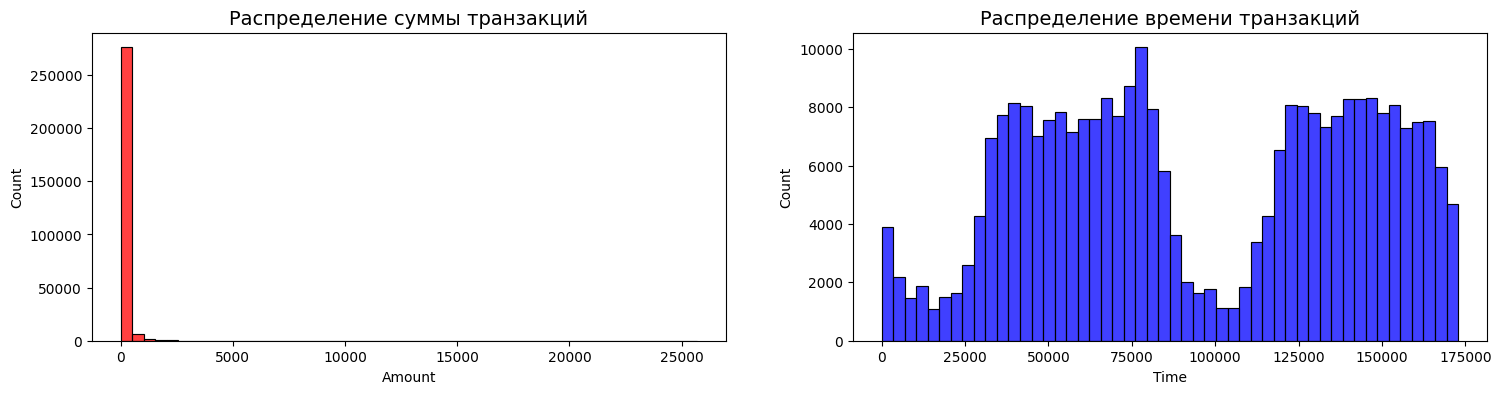

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], ax=ax[0], color='r', bins=50)
ax[0].set_title('Распределение суммы транзакций', fontsize=14)

sns.histplot(df['Time'], ax=ax[1], color='b', bins=50)
ax[1].set_title('Распределение времени транзакций', fontsize=14)

plt.show()

### Визуализация распределения `Time` и `Amount`

Признаки V1–V28 анонимизированы (PCA), поэтому для интерпретируемого EDA имеет смысл отдельно посмотреть на `Time` и `Amount`.

## Препроцессинг: масштабирование `Time` и `Amount`

Остальные признаки (`V1–V28`) уже нормализованы (PCA), но `Time` и `Amount` — нет. Поэтому стандартизируем их и удаляем исходные колонки.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Если вы запускаете ноутбук повторно, столбцы Time/Amount могут быть уже удалены.
# Сделаем ячейку идемпотентной.
if 'Amount' in df.columns:
    df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
if 'Time' in df.columns:
    df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

cols_to_drop = [c for c in ['Time', 'Amount'] if c in df.columns]
if cols_to_drop:
    df.drop(cols_to_drop, axis=1, inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Признаки/таргет
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified split — обязательно при дисбалансе
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Logistic Regression baseline
lr = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
)

lr.fit(X_train, y_train)

y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print('LogReg ROC-AUC:', roc_auc_score(y_test, y_proba_lr))
print('LogReg PR-AUC (AP):', average_precision_score(y_test, y_proba_lr))
print('\nConfusion matrix (threshold=0.5):')
print(confusion_matrix(y_test, y_pred_lr))
print('\nClassification report:')
print(classification_report(y_test, y_pred_lr, digits=4))

LogReg ROC-AUC: 0.9720948047902335
LogReg PR-AUC (AP): 0.7189348125855012

Confusion matrix (threshold=0.5):
[[55478  1386]
 [    8    90]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



## Baseline: логистическая регрессия (учёт дисбаланса)

Делаем первый честный baseline на *исходном дисбалансе*, но с `class_weight='balanced'`.
Смотрим ROC-AUC и PR-AUC (AP), а также confusion matrix при пороге 0.5.

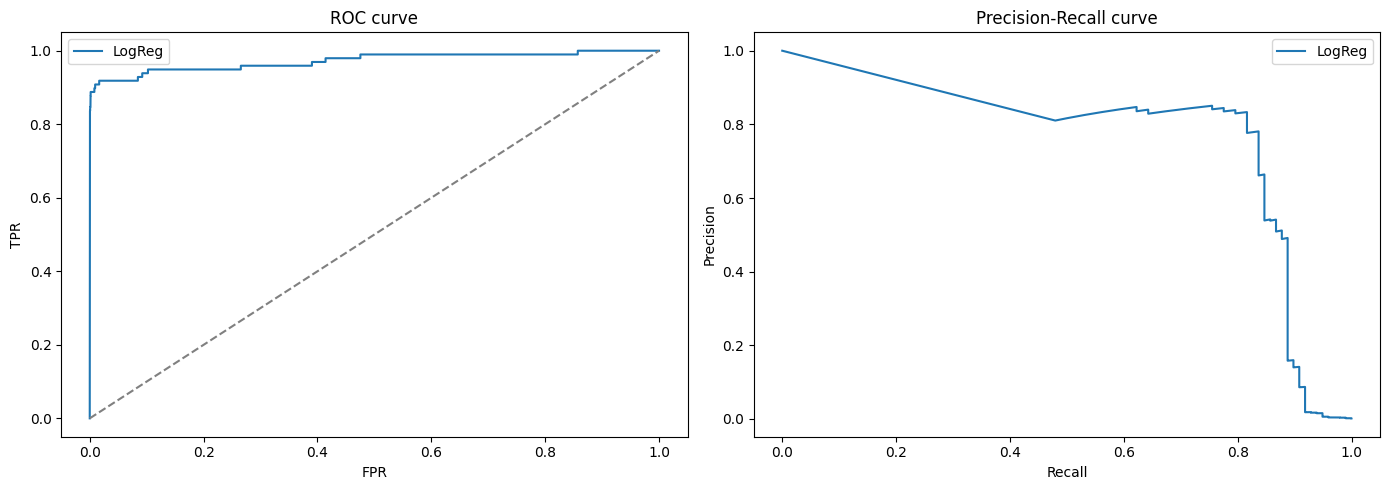

In [7]:
# ROC и PR кривые (после обучения модели)
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(fpr, tpr, label='LogReg')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[0].set_title('ROC curve')
ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[0].legend()

ax[1].plot(rec, prec, label='LogReg')
ax[1].set_title('Precision-Recall curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.tight_layout()
plt.show()

## Сравнение моделей: LogReg vs RandomForest vs XGBoost

Сравним модели на одном и том же `train/test split` и посмотрим ROC-AUC и PR-AUC (Average Precision).

Для XGBoost учитываем дисбаланс через `scale_pos_weight ≈ N_neg / N_pos` на трейне.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Вспомогательная функция для сравнения

def eval_model(name, model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
    }

# RandomForest baseline (не требует масштабирования, но у нас оно уже сделано)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
)
rf.fit(X_train, y_train)

# XGBoost baseline
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg) / float(pos)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)
xgb.fit(X_train, y_train)

results = []
results.append({'model': 'LogReg', 'roc_auc': roc_auc_score(y_test, y_proba_lr), 'pr_auc': average_precision_score(y_test, y_proba_lr)})
results.append(eval_model('RandomForest', rf, X_test, y_test))
results.append(eval_model('XGBoost', xgb, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df

,model,roc_auc,pr_auc
2,XGBoost,0.984916,0.871297
1,RandomForest,0.961545,0.865242
0,LogReg,0.972095,0.718935


In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

# В xgboost==3.2.0 у sklearn-обёртки нет early stopping в .fit(),
# поэтому обучаем финальную модель *без* early stopping, но ставим n_estimators поменьше.
best_params = study.best_params.copy()

# Маппинг названий параметров из xgb.train -> sklearn wrapper
best_params_sklearn = {
    'learning_rate': best_params['eta'],
    'max_depth': best_params['max_depth'],
    'min_child_weight': best_params['min_child_weight'],
    'subsample': best_params['subsample'],
    'colsample_bytree': best_params['colsample_bytree'],
    'gamma': best_params['gamma'],
    'reg_lambda': best_params['lambda'],
    'reg_alpha': best_params['alpha'],
}

# Учим на полном train и оцениваем на test
xgb_opt = XGBClassifier(
    n_estimators=1200,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    **best_params_sklearn,
)

# no early stopping (API change in xgboost>=3)
xgb_opt.fit(X_train, y_train, verbose=False)

# Метрики на test
y_proba_opt = xgb_opt.predict_proba(X_test)[:, 1]
roc_auc_opt = roc_auc_score(y_test, y_proba_opt)
pr_auc_opt = average_precision_score(y_test, y_proba_opt)

print(f'Tuned XGBoost ROC-AUC: {roc_auc_opt:.6f}')
print(f'Tuned XGBoost PR-AUC:  {pr_auc_opt:.6f}')

Tuned XGBoost ROC-AUC: 0.973342
Tuned XGBoost PR-AUC:  0.875865


In [ ]:
import xgboost as xgb
xgb.__version__

## Optuna: тюнинг XGBoost под PR-AUC

В `xgboost==3.x` у sklearn-обёртки изменился API ранней остановки, поэтому для Optuna используем `xgboost.train()` + `DMatrix`, где `early_stopping_rounds` работает корректно.